In [1]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/drive/MyDrive/data_banknote_authentication.csv')
print("Shape:", df.shape)
df.head()

Mounted at /content/drive
Shape: (1372, 5)


,Variance_Wavelet,Skewness_Wavelet,Curtosis_Wavelet,Image_Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Variance_Wavelet  1372 non-null   float64
 1   Skewness_Wavelet  1372 non-null   float64
 2   Curtosis_Wavelet  1372 non-null   float64
 3   Image_Entropy     1372 non-null   float64
 4   Class             1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [3]:
print("Class distribution:")
print(df['Class'].value_counts())
# 0 = Authentic, 1 = Forged

Class distribution:
Class
0    762
1    610
Name: count, dtype: int64


In [4]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)

Train size: (960, 4)
Test size:  (412, 4)


In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

dt_param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 3, 5, 10, 15],
    'max_leaf_nodes': [None, 5, 10, 20]
}

dt = DecisionTreeClassifier(random_state=42)

dt_grid = GridSearchCV(dt, dt_param_grid, scoring='accuracy', cv=5)
dt_grid.fit(X_train, y_train)

print("Best Decision Tree Parameters:", dt_grid.best_params_)
print("Best CV Accuracy:", round(dt_grid.best_score_, 4))

Best Decision Tree Parameters: {'criterion': 'entropy', 'max_depth': None, 'max_leaf_nodes': 20}
Best CV Accuracy: 0.9865


=== Decision Tree — Confusion Matrix ===


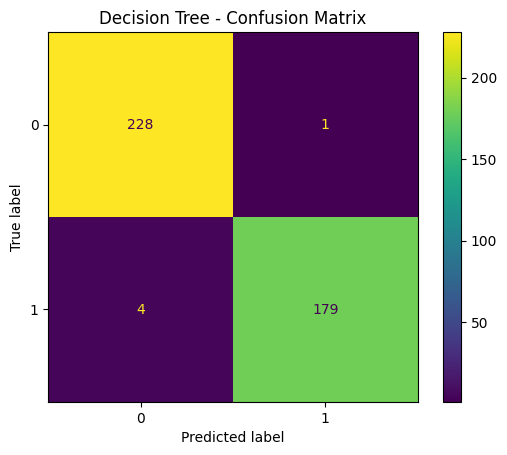


=== Decision Tree — Classification Report ===
              precision    recall  f1-score   support

   Authentic       0.98      1.00      0.99       229
      Forged       0.99      0.98      0.99       183

    accuracy                           0.99       412
   macro avg       0.99      0.99      0.99       412
weighted avg       0.99      0.99      0.99       412



In [6]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

dt_preds = dt_grid.predict(X_test)

print("=== Decision Tree — Confusion Matrix ===")
ConfusionMatrixDisplay.from_predictions(y_test, dt_preds)
plt.title("Decision Tree - Confusion Matrix")
plt.show()

print("\n=== Decision Tree — Classification Report ===")
print(classification_report(y_test, dt_preds, target_names=['Authentic', 'Forged']))

In [7]:
from sklearn.ensemble import RandomForestClassifier

rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=42)

rf_grid = GridSearchCV(rf, rf_param_grid, scoring='accuracy', cv=5)
rf_grid.fit(X_train, y_train)

print("Best Random Forest Parameters:", rf_grid.best_params_)
print("Best CV Accuracy:", round(rf_grid.best_score_, 4))

Best Random Forest Parameters: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 50}
Best CV Accuracy: 0.9917


=== Random Forest — Confusion Matrix ===


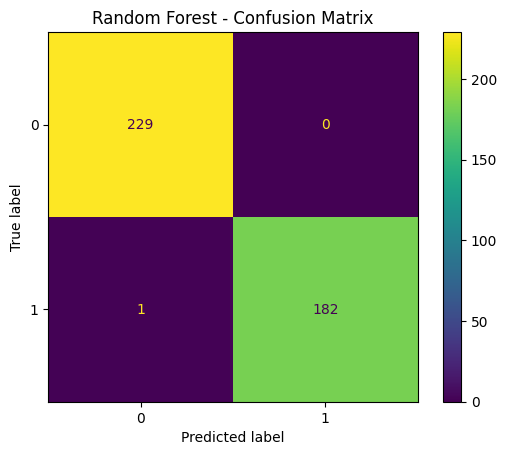


=== Random Forest — Classification Report ===
              precision    recall  f1-score   support

   Authentic       1.00      1.00      1.00       229
      Forged       1.00      0.99      1.00       183

    accuracy                           1.00       412
   macro avg       1.00      1.00      1.00       412
weighted avg       1.00      1.00      1.00       412



In [8]:
rf_preds = rf_grid.predict(X_test)

print("=== Random Forest — Confusion Matrix ===")
ConfusionMatrixDisplay.from_predictions(y_test, rf_preds)
plt.title("Random Forest - Confusion Matrix")
plt.show()

print("\n=== Random Forest — Classification Report ===")
print(classification_report(y_test, rf_preds, target_names=['Authentic', 'Forged']))

In [9]:
from sklearn.metrics import accuracy_score

dt_acc  = accuracy_score(y_test, dt_preds)
rf_acc  = accuracy_score(y_test, rf_preds)

print("=" * 45)
print(f"  Decision Tree  Test Accuracy: {dt_acc:.4f}")
print(f"  Random Forest  Test Accuracy: {rf_acc:.4f}")
print("=" * 45)

if rf_acc > dt_acc:
    print("✅ Random Forest performs BETTER on this dataset.")
elif dt_acc > rf_acc:
    print("✅ Decision Tree performs BETTER on this dataset.")
else:
    print("Both models perform equally.")

print("""
=== Discussion ===
- Random Forest is an ensemble of many decision trees trained on random subsets
  of the data (Bagging), which reduces overfitting and variance.
- Decision Tree is a single tree that can overfit if not properly pruned,
  but is more interpretable.
- For the Banknote Authentication dataset, Random Forest typically achieves
  higher accuracy and better generalisation because it leverages the
  diversity of multiple trees to reduce noise in predictions.
""")

  Decision Tree  Test Accuracy: 0.9879
  Random Forest  Test Accuracy: 0.9976
✅ Random Forest performs BETTER on this dataset.

=== Discussion ===
- Random Forest is an ensemble of many decision trees trained on random subsets
  of the data (Bagging), which reduces overfitting and variance.
- Decision Tree is a single tree that can overfit if not properly pruned,
  but is more interpretable.
- For the Banknote Authentication dataset, Random Forest typically achieves
  higher accuracy and better generalisation because it leverages the 
  diversity of multiple trees to reduce noise in predictions.

